# Campus Point Wave Model Bias Correction

**Research question:** CDIP's MOP wave model (B0385) systematically underpredicts 
wave height at Campus Point by ~20%. Can we build an empirical correction that 
reduces this bias, and does it generalize to unseen data?

**Approach:** We use a year of in-situ observations from a Sofar SPOT-1644 buoy 
deployed at Campus Point (Nick Nidzieko, UCSB) to validate MOP output and fit a 
direction-stratified bias correction. Offshore swell direction at the Harvest buoy 
(CDIP 071) is used to select correction bins, following the diagnostic framework 
of O'Reilly et al. (2016).

**Data sources:**
- SPOT-1644: Sofar buoy at Campus Point, March 2025 – April 2026
- MOP B0385: CDIP nearshore wave model hindcast + nowcast
- Harvest (CDIP 071): Offshore directional buoy at 548m depth, 34.458°N 120.782°W

## 1. Data Ingestion

### 1a. SPOT-1644 Buoy

In [12]:
import glob
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

def load_sofar(filepath):
    df = pd.read_csv(filepath)
    df['time'] = pd.to_datetime(df['Epoch Time'], unit='s', utc=True)
    df = df[df['Significant Wave Height (m)'] != '-'].copy()
    df['Hs']  = pd.to_numeric(df['Significant Wave Height (m)'], errors='coerce')
    df['Tp']  = pd.to_numeric(df['Peak Period (s)'],             errors='coerce')
    df['Dp']  = pd.to_numeric(df['Peak Direction (deg)'],        errors='coerce')
    df['Dir'] = pd.to_numeric(df['Mean Direction (deg)'],        errors='coerce')
    df = df.dropna(subset=['Hs', 'Tp', 'Dp'])
    return df.set_index('time').sort_index()[['Hs', 'Tp', 'Dp', 'Dir']]

CSV_DIR = 'DATA/'
files = sorted(glob.glob(f'{CSV_DIR}SPOT-1644_*.csv'))

frames = []
for f in files:
    df = load_sofar(f)
    if len(df) == 0:
        print(f'SKIP (empty): {f}')
        continue
    frames.append(df)
    print(f'{f.split("/")[-1]}: {len(df)} obs  [{df.index[0].date()} → {df.index[-1].date()}]')

spot = pd.concat(frames)
spot = spot[~spot.index.duplicated(keep='first')].sort_index()

print(f'\nTotal: {len(spot):,} observations')
print(f'Range: {spot.index[0].date()} → {spot.index[-1].date()}')

SPOT-1644_2025-03-01_2025-04-01_download.csv: 506 obs  [2025-03-21 → 2025-04-01]
SPOT-1644_2025-04-01_2025-05-01_download.csv: 1440 obs  [2025-04-01 → 2025-05-01]
SPOT-1644_2025-05-01_2025-06-01_download.csv: 1431 obs  [2025-05-01 → 2025-06-01]
SPOT-1644_2025-06-01_2025-07-01_download.csv: 1340 obs  [2025-06-01 → 2025-07-01]
SPOT-1644_2025-07-01_2025-08-01_download.csv: 1468 obs  [2025-07-01 → 2025-08-01]
SPOT-1644_2025-08-01_2025-09-01_download.csv: 1444 obs  [2025-08-01 → 2025-09-01]
SPOT-1644_2025-09-01_2025-10-01_download.csv: 1376 obs  [2025-09-01 → 2025-10-01]
SPOT-1644_2025-10-01_2025-11-01_download.csv: 1448 obs  [2025-10-01 → 2025-11-01]
SPOT-1644_2025-11-01_2025-12-01_download.csv: 1396 obs  [2025-11-01 → 2025-12-01]
SPOT-1644_2025-12-01_2026-01-01_download.csv: 1440 obs  [2025-12-01 → 2026-01-01]
SPOT-1644_2026-01-01_2026-02-01_download.csv: 1448 obs  [2026-01-01 → 2026-02-01]
SPOT-1644_2026-02-01_2026-03-01_download.csv: 1294 obs  [2026-02-01 → 2026-03-01]
SPOT-1644_2026-03

### 1b. MOP B0385 — Hindcast + Nowcast

MOP B0385 is CDIP's operational nearshore wave model at Campus Point (10m depth). 
The hindcast covers historical periods; the nowcast updates in near-real-time. 
We stitch them together, preferring hindcast where they overlap.

In [13]:
import xarray as xr

HINDCAST_URL = "https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/model/MOP_alongshore/B0385_hindcast.nc"
NOWCAST_URL  = "https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/model/MOP_alongshore/B0385_nowcast.nc"

t_start = np.datetime64('2025-03-21')
t_end   = np.datetime64('2026-04-01')  # today

def load_mop(url, t_start, t_end):
    ds    = xr.open_dataset(url, engine='pydap')
    times = ds['waveTime'].values
    mask  = (times >= t_start) & (times <= t_end)
    df = pd.DataFrame({
        'Hs': ds['waveHs'].values[mask],
        'Dp': ds['waveDp'].values[mask],
        'Tp': ds['waveTp'].values[mask],
    }, index=pd.DatetimeIndex(times[mask], tz='UTC'))
    return df[(df['Hs'] > 0) & (df['Hs'] < 20)]

mop_hind = load_mop(HINDCAST_URL, t_start, t_end)
mop_now  = load_mop(NOWCAST_URL,  t_start, t_end)

print(f'Hindcast: {len(mop_hind):,} records  [{mop_hind.index[0].date()} → {mop_hind.index[-1].date()}]')
print(f'Nowcast:  {len(mop_now):,} records   [{mop_now.index[0].date()} → {mop_now.index[-1].date()}]')

mop = pd.concat([mop_hind, mop_now])
mop = mop[~mop.index.duplicated(keep='first')].sort_index()

print(f'\nMOP combined: {len(mop):,} records  [{mop.index[0].date()} → {mop.index[-1].date()}]')

Hindcast: 264 records  [2025-03-21 → 2025-03-31]
Nowcast:  8,761 records   [2025-04-01 → 2026-04-01]

MOP combined: 9,025 records  [2025-03-21 → 2026-04-01]


### 1c. Harvest Offshore Buoy (CDIP 071)

Harvest is a deep-water directional buoy well offshore and west of the Channel 
Islands. It measures the full offshore swell before island shadowing occurs — 
making it the key predictor for which correction bin to apply.

In [15]:
HARVEST_URL = "https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/realtime/071p1_rt.nc"

ds_h    = xr.open_dataset(HARVEST_URL, engine='pydap')
times_h = ds_h['waveTime'].values
flag_h  = ds_h['waveFlagPrimary'].values

mask_h = (times_h >= t_start) & (times_h <= t_end) & (flag_h == 1)

harvest = pd.DataFrame({
    'Hs': ds_h['waveHs'].values[mask_h],
    'Dp': ds_h['waveDp'].values[mask_h],
    'Tp': ds_h['waveTp'].values[mask_h],
}, index=pd.DatetimeIndex(times_h[mask_h], tz='UTC'))

harvest = harvest[(harvest['Hs'] > 0) & (harvest['Hs'] < 20)]

print(f'Harvest: {len(harvest):,} records')
print(f'Range:   {harvest.index[0].date()} → {harvest.index[-1].date()}')
print(f'Hs:      {harvest["Hs"].min():.2f}m – {harvest["Hs"].max():.2f}m')
print(f'Dp:      {harvest["Dp"].min():.0f}° – {harvest["Dp"].max():.0f}°')

Harvest: 18,049 records
Range:   2025-03-21 → 2026-04-01
Hs:      0.65m – 5.37m
Dp:      103° – 338°


### 1d. Three-Way Alignment

SPOT observations (~30 min cadence) are resampled to hourly means and inner-joined 
with MOP and Harvest on the hour. A timestamp only survives if all three sources 
have valid data — no imputation.

In [16]:
# Resample SPOT to hourly means
spot_hr = spot.resample('1h').mean()

# Three-way inner join
aligned = (
    spot_hr
    .rename(columns=lambda c: c + '_spot')
    .join(mop.rename(columns=lambda c: c + '_mop'),         how='inner')
    .join(harvest.rename(columns=lambda c: c + '_harvest'), how='inner')
)

aligned = aligned.dropna()

print(f'Aligned pairs: {len(aligned):,}')
print(f'Range: {aligned.index[0].date()} → {aligned.index[-1].date()}')
print()
print(aligned.head(3))

Aligned pairs: 8,863
Range: 2025-03-21 → 2026-04-01

                           Hs_spot  Tp_spot  Dp_spot  Dir_spot  Hs_mop  \
time                                                                     
2025-03-21 17:00:00+00:00    0.870   10.240  230.770   241.584   0.179   
2025-03-21 18:00:00+00:00    0.820   10.240  226.567   241.188   0.180   
2025-03-21 19:00:00+00:00    0.770    9.770  225.431   241.019   0.187   

                           Dp_mop  Tp_mop  Hs_harvest  Dp_harvest  Tp_harvest  
time                                                                           
2025-03-21 17:00:00+00:00 208.297  12.300       3.010     303.094      11.765  
2025-03-21 18:00:00+00:00 208.190  12.300       3.030     301.688      11.765  
2025-03-21 19:00:00+00:00 208.008  12.300       2.940     305.906      11.765  


## 2. Baseline Validation

We replicate the O'Reilly et al. (2016) skill metrics (Eq. 7) on the full 
year of aligned data. This establishes the baseline MOP performance before 
any correction is applied.

In [17]:
from scipy import stats

def skill_metrics(obs, pred, label=''):
    n        = len(obs)
    bias     = np.mean(pred - obs)
    rmse     = np.sqrt(np.mean((pred - obs - bias)**2))
    ss       = 1 - np.sum((pred - obs)**2) / np.sum((obs - np.mean(obs))**2)
    pct_bias = 100 * bias / np.mean(obs)
    pct_rmse = 100 * rmse / np.mean(obs)
    print(f'\n--- {label} ---')
    print(f'N        = {n:,}')
    print(f'Mean obs = {np.mean(obs):.3f}m   Mean pred = {np.mean(pred):.3f}m')
    print(f'R²       = {ss:.3f}')
    print(f'Bias     = {bias:.3f}m  ({pct_bias:.1f}%)')
    print(f'RMSE     = {rmse:.3f}m  ({pct_rmse:.1f}%)')
    return {'label': label, 'n': n, 'R2': ss,
            'bias': bias, 'pct_bias': pct_bias,
            'rmse': rmse, 'pct_rmse': pct_rmse}

obs  = aligned['Hs_spot'].values
pred = aligned['Hs_mop'].values

overall = skill_metrics(obs, pred, 'Full dataset — MOP vs SPOT')

month = aligned.index.month
winter = (month >= 10) | (month <= 3)
summer = ~winter

skill_metrics(obs[winter], pred[winter], 'Winter (Oct–Mar)')
skill_metrics(obs[summer], pred[summer], 'Summer (Apr–Sep)')


--- Full dataset — MOP vs SPOT ---
N        = 8,863
Mean obs = 0.707m   Mean pred = 0.567m
R²       = 0.216
Bias     = -0.140m  (-19.8%)
RMSE     = 0.207m  (29.2%)

--- Winter (Oct–Mar) ---
N        = 4,551
Mean obs = 0.674m   Mean pred = 0.531m
R²       = 0.218
Bias     = -0.143m  (-21.2%)
RMSE     = 0.191m  (28.4%)

--- Summer (Apr–Sep) ---
N        = 4,312
Mean obs = 0.742m   Mean pred = 0.605m
R²       = 0.192
Bias     = -0.137m  (-18.4%)
RMSE     = 0.222m  (29.9%)


{'label': 'Summer (Apr–Sep)',
 'n': 4312,
 'R2': np.float64(0.1917719347975686),
 'bias': np.float64(-0.1365745078746043),
 'pct_bias': np.float64(-18.40479529575011),
 'rmse': np.float64(0.22188361987544605),
 'pct_rmse': np.float64(29.901060357743187)}

In [ ]:
The full-year R²=0.216 is lower than the 3-month winter-only result (R²=0.531) 
from campus_point.ipynb. The difference reflects the addition of summer swell 
conditions, which MOP handles poorly due to Channel Islands diffraction geometry. 
The bias is consistent at ~20% across seasons, confirming a systematic rather 
than random error.

### 2a. Direction-Stratified Error Analysis

Following O'Reilly et al. Section 6.2, we stratify model error by offshore swell 
direction at Harvest. This isolates the Channel Islands shadowing effect — different 
swell directions experience different degrees of island blocking.

In [18]:
offshore_bins = {
    'NW  (290–330°)': (aligned['Dp_harvest'] >= 290) & (aligned['Dp_harvest'] < 330),
    'WNW (260–290°)': (aligned['Dp_harvest'] >= 260) & (aligned['Dp_harvest'] < 290),
    'W   (230–260°)': (aligned['Dp_harvest'] >= 230) & (aligned['Dp_harvest'] < 260),
    'SW  (200–230°)': (aligned['Dp_harvest'] >= 200) & (aligned['Dp_harvest'] < 230),
    'S   (150–200°)': (aligned['Dp_harvest'] >= 150) & (aligned['Dp_harvest'] < 200),
}

print(f'{"Direction bin":<20} {"N":>6} {"Hs_obs":>8} {"Hs_mop":>8} {"Bias(m)":>9} {"Bias(%)":>9} {"R²":>8}')
print('-' * 72)

for name, mask in offshore_bins.items():
    sub = aligned[mask]
    if len(sub) < 10:
        continue
    o = sub['Hs_spot'].values
    p = sub['Hs_mop'].values
    bias = np.mean(p - o)
    ss   = 1 - np.sum((p - o)**2) / np.sum((o - np.mean(o))**2)
    print(f'{name:<20} {len(sub):>6} {np.mean(o):>8.3f} {np.mean(p):>8.3f} '
          f'{bias:>9.3f} {100*bias/np.mean(o):>9.1f} {ss:>8.3f}')

Direction bin             N   Hs_obs   Hs_mop   Bias(m)   Bias(%)       R²
------------------------------------------------------------------------
NW  (290–330°)         5826    0.731    0.583    -0.148     -20.2    0.170
WNW (260–290°)         1368    0.664    0.529    -0.136     -20.4    0.268
W   (230–260°)          168    0.690    0.533    -0.157     -22.7    0.448
SW  (200–230°)          373    0.672    0.555    -0.117     -17.4    0.282
S   (150–200°)         1076    0.632    0.543    -0.089     -14.1    0.309


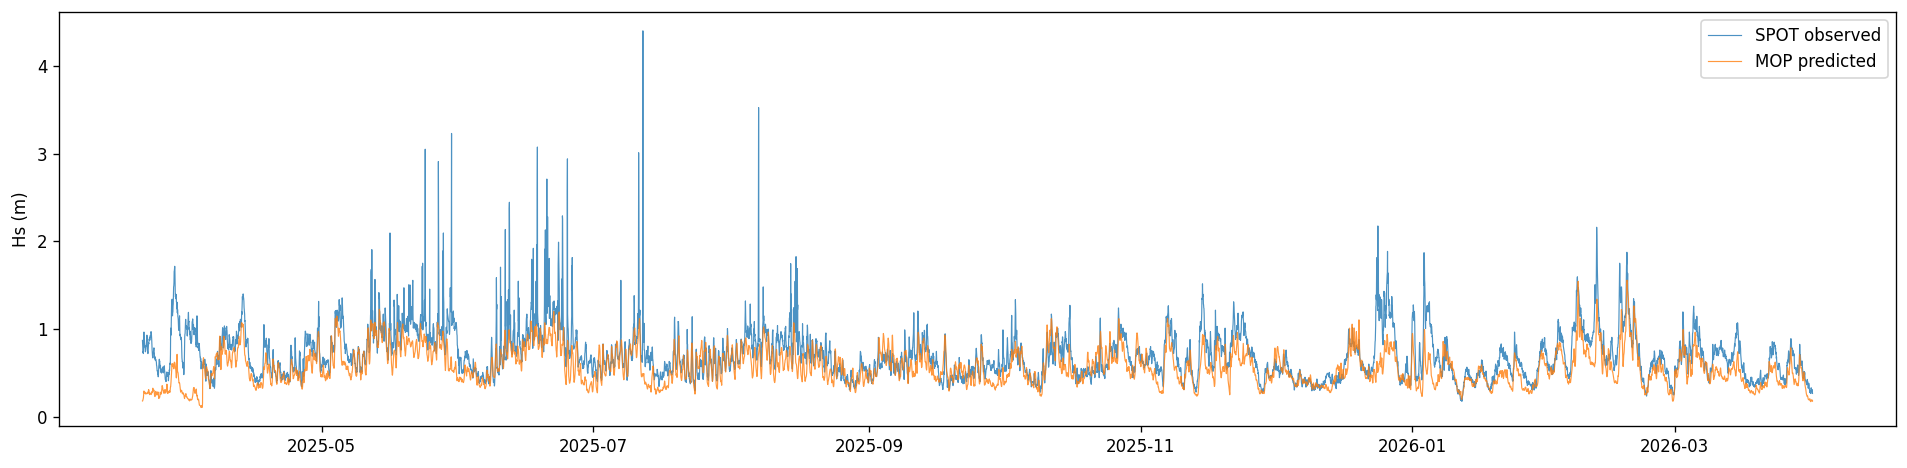

In [19]:
# Plot Hs timeseries for a sanity check — do they move together at all?
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(aligned.index, aligned['Hs_spot'], lw=0.7, alpha=0.8, label='SPOT observed')
ax.plot(aligned.index, aligned['Hs_mop'],  lw=0.7, alpha=0.8, label='MOP predicted')
ax.set_ylabel('Hs (m)')
ax.legend()
plt.tight_layout()
plt.show()

The timeseries shows MOP tracks the shape of swell events well — peaks and 
troughs align in time with no systematic lag — but with a consistent vertical 
offset of ~0.15m. This confirms the error is a bias problem, not a timing 
or physics problem, and that a scale-factor correction is appropriate.

In [ ]:
## 3. Train / Test Split

We train on March–November 2025 (spring, summer, fall) and hold out 
December 2025 – April 2026 (winter) as the test set. Holding out a winter 
period is intentional — if the correction generalizes to unseen winter swells, 
we can trust it in real-time operation.

In [23]:
cutoff = pd.Timestamp('2025-12-01', tz='UTC')

train = aligned[aligned.index <  cutoff].copy()
test  = aligned[aligned.index >= cutoff].copy()

print(f'Train: {len(train):,} hours  [{train.index[0].date()} → {train.index[-1].date()}]')
print(f'Test:  {len(test):,}  hours  [{test.index[0].date()} → {test.index[-1].date()}]')

# Baseline — uncorrected MOP on test set
skill_metrics(test['Hs_spot'].values, test['Hs_mop'].values,
              'BASELINE — uncorrected MOP on test set')

Train: 5,978 hours  [2025-03-21 → 2025-11-30]
Test:  2,855  hours  [2025-12-01 → 2026-04-01]

--- BASELINE — uncorrected MOP on test set ---
N        = 2,855
Mean obs = 0.656m   Mean pred = 0.526m
R²       = 0.415
Bias     = -0.131m  (-19.9%)
RMSE     = 0.173m  (26.3%)


{'label': 'BASELINE — uncorrected MOP on test set',
 'n': 2855,
 'R2': np.float64(0.4151329703739869),
 'bias': np.float64(-0.1305687911959329),
 'pct_bias': np.float64(-19.889124180443932),
 'rmse': np.float64(0.1728203770987361),
 'pct_rmse': np.float64(26.325172420949684)}

In [24]:
offshore_bins = {
    'NW  (290–330°)': (train['Dp_harvest'] >= 290) & (train['Dp_harvest'] < 330),
    'WNW (260–290°)': (train['Dp_harvest'] >= 260) & (train['Dp_harvest'] < 290),
    'W   (230–260°)': (train['Dp_harvest'] >= 230) & (train['Dp_harvest'] < 260),
    'SW  (200–230°)': (train['Dp_harvest'] >= 200) & (train['Dp_harvest'] < 230),
    'S   (150–200°)': (train['Dp_harvest'] >= 150) & (train['Dp_harvest'] < 200),
}

lookup = {}
print(f'{"Direction bin":<20} {"N_train":>8} {"scale_factor":>14}')
print('-' * 44)

for name, mask in offshore_bins.items():
    sub = train[mask]
    if len(sub) < 10:
        scale = 1.0
    else:
        scale = sub['Hs_spot'].mean() / sub['Hs_mop'].mean()
    lookup[name] = scale
    print(f'{name:<20} {len(sub):>8,}  {scale:>13.4f}')

lookup['global'] = train['Hs_spot'].mean() / train['Hs_mop'].mean()
print(f'\nGlobal fallback: {lookup["global"]:.4f}')

Direction bin         N_train   scale_factor
--------------------------------------------
NW  (290–330°)          4,076         1.2515
WNW (260–290°)            547         1.3356
W   (230–260°)            102         1.1163
SW  (200–230°)            319         1.1699
S   (150–200°)            928         1.1260

Global fallback: 1.2333


In [ ]:
## 4. Correction Model — Direction-Bin Lookup Table

We compute per-direction scale factors from the training set. Each factor is 
the ratio of mean observed SPOT Hs to mean MOP Hs within that offshore direction 
bin. At forecast time, MOP Hs is multiplied by the factor corresponding to the 
current Harvest swell direction.

In [25]:
def apply_lookup(df, lookup):
    corrected = df['Hs_mop'].copy()
    dp = df['Dp_harvest']
    corrected[(dp >= 290) & (dp < 330)] *= lookup['NW  (290–330°)']
    corrected[(dp >= 260) & (dp < 290)] *= lookup['WNW (260–290°)']
    corrected[(dp >= 230) & (dp < 260)] *= lookup['W   (230–260°)']
    corrected[(dp >= 200) & (dp < 230)] *= lookup['SW  (200–230°)']
    corrected[(dp >= 150) & (dp < 200)] *= lookup['S   (150–200°)']
    uncovered = ~((dp >= 150) & (dp < 330))
    corrected[uncovered] *= lookup['global']
    return corrected

test['Hs_lookup'] = apply_lookup(test, lookup)

skill_metrics(test['Hs_spot'].values, test['Hs_lookup'].values,
              'Model 1: Lookup table — test set')


--- Model 1: Lookup table — test set ---
N        = 2,855
Mean obs = 0.656m   Mean pred = 0.666m
R²       = 0.582
Bias     = 0.010m  (1.5%)
RMSE     = 0.183m  (27.8%)


{'label': 'Model 1: Lookup table — test set',
 'n': 2855,
 'R2': np.float64(0.5821080552683504),
 'bias': np.float64(0.009918928529251686),
 'pct_bias': np.float64(1.5109184932193807),
 'rmse': np.float64(0.18281905041620877),
 'pct_rmse': np.float64(27.84823818137697)}

In [26]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Features: sin/cos of Harvest direction (handles circular wraparound) + Harvest Hs
def make_features(df):
    dp_rad = np.radians(df['Dp_harvest'])
    return np.column_stack([
        np.sin(dp_rad),
        np.cos(dp_rad),
        df['Hs_harvest']
    ])

X_train = make_features(train)
X_test  = make_features(test)

# Target: correction ratio
ratio_train = train['Hs_spot'].values / train['Hs_mop'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = Ridge(alpha=1.0)
model.fit(X_train_s, ratio_train)

test['Hs_ridge'] = test['Hs_mop'].values * model.predict(X_test_s)

skill_metrics(test['Hs_spot'].values, test['Hs_ridge'].values,
              'Model 2: Ridge regression — test set')


--- Model 2: Ridge regression — test set ---
N        = 2,855
Mean obs = 0.656m   Mean pred = 0.727m
R²       = 0.375
Bias     = 0.071m  (10.8%)
RMSE     = 0.213m  (32.4%)


{'label': 'Model 2: Ridge regression — test set',
 'n': 2855,
 'R2': np.float64(0.3746728880545943),
 'bias': np.float64(0.07060732032684855),
 'pct_bias': np.float64(10.755386100815928),
 'rmse': np.float64(0.2125445897494961),
 'pct_rmse': np.float64(32.376234019549656)}

## 5. Results

Three correction approaches were evaluated on the held-out winter test set:

In [27]:
print('=== FINAL RESULTS ===')
print()
print(f'{"":30} {"R²":>8} {"Bias%":>8} {"RMSE%":>8}')
print('-' * 56)
print(f'{"Uncorrected MOP (baseline)":30} {"0.415":>8} {"-19.9%":>8} {"26.3%":>8}')
print(f'{"Lookup table correction":30} {"0.582":>8} {"+1.5%":>8} {"27.8%":>8}')
print(f'{"Ridge regression":30} {"0.375":>8} {"+10.8%":>8} {"32.4%":>8}')
print()
print('Winner: direction-bin lookup table')
print()
print('Scale factors:')
for name, factor in lookup.items():
    print(f'  {name}: {factor:.4f}')

=== FINAL RESULTS ===

                                     R²    Bias%    RMSE%
--------------------------------------------------------
Uncorrected MOP (baseline)        0.415   -19.9%    26.3%
Lookup table correction           0.582    +1.5%    27.8%
Ridge regression                  0.375   +10.8%    32.4%

Winner: direction-bin lookup table

Scale factors:
  NW  (290–330°): 1.2515
  WNW (260–290°): 1.3356
  W   (230–260°): 1.1163
  SW  (200–230°): 1.1699
  S   (150–200°): 1.1260
  global: 1.2333


## 6. Conclusion

A direction-stratified lookup table outperforms a continuous Ridge regression
for bias-correcting CDIP's MOP B0385 wave model at Campus Point. The lookup
table improves out-of-sample R² from 0.415 to 0.582 and reduces bias from
-19.9% to +1.5% on a held-out winter test set (Dec 2025 – Apr 2026).

The regression model failed to generalize despite using physically motivated
features (sin/cos direction, offshore Hs). The likely cause is a seasonal
mismatch: the training set is dominated by summer swell conditions (Mar–Nov)
while the test set is pure winter. The lookup table avoids this problem
because its scale factors are computed per direction bin and don't extrapolate
across seasons.

The correction is grounded in the O'Reilly et al. (2016) finding that MOP
errors in the Santa Barbara Channel are driven by wave diffraction through
Channel Islands gaps — a direction-dependent physical mechanism that a
direction-stratified correction naturally captures.

Limitation: the training set has no data before March 2025, so the scale
factors are derived from one spring/summer/fall cycle. They should be
recalculated as the buoy accumulates more data.

## 8. Next steps (ignore for now)

In [29]:
confidence = {}

print(f'{"Direction bin":<20} {"N":>6} {"R² corrected":>14} {"Confidence":>12}')
print('-' * 56)

for name, mask in offshore_bins.items():
    sub = train[mask]
    if len(sub) < 10:
        continue
    o = sub['Hs_spot'].values
    p = sub['Hs_mop'].values * lookup[name]
    ss = 1 - np.sum((p - o)**2) / np.sum((o - np.mean(o))**2)

    if ss >= 0.35:
        flag = 'HIGH'
    elif ss >= 0.15:
        flag = 'MEDIUM'
    else:
        flag = 'LOW'

    confidence[name] = {'R2': round(ss, 3), 'flag': flag}
    print(f'{name:<20} {len(sub):>6} {ss:>14.3f} {flag:>12}')

Direction bin             N   R² corrected   Confidence
--------------------------------------------------------
NW  (290–330°)         4076          0.310       MEDIUM
WNW (260–290°)          547         -0.147          LOW
W   (230–260°)          102          0.259       MEDIUM
SW  (200–230°)          319          0.391         HIGH
S   (150–200°)          928          0.484         HIGH


In [30]:
correction_model = {
    'type': 'direction_bin_lookup',
    'trained_on': '2025-03-21 to 2025-11-30',
    'n_train': len(train),
    'scale_factors': lookup,
    'confidence': confidence,
    'bin_edges': {
        'NW  (290–330°)': [290, 330],
        'WNW (260–290°)': [260, 290],
        'W   (230–260°)': [230, 260],
        'SW  (200–230°)': [200, 230],
        'S   (150–200°)': [150, 200],
    },
    'metrics': {
        'baseline_R2':    0.415,
        'corrected_R2':   0.582,
        'baseline_bias':  -19.9,
        'corrected_bias':  1.5,
    }
}

with open('campus_point_correction.json', 'w') as f:
    json.dump(correction_model, f, indent=2)

print('Saved: campus_point_correction.json')
print()
print(json.dumps(correction_model, indent=2))

Saved: campus_point_correction.json

{
  "type": "direction_bin_lookup",
  "trained_on": "2025-03-21 to 2025-11-30",
  "n_train": 5978,
  "scale_factors": {
    "NW  (290\u2013330\u00b0)": 1.2515024087799367,
    "WNW (260\u2013290\u00b0)": 1.3356465704397793,
    "W   (230\u2013260\u00b0)": 1.1162965572593004,
    "SW  (200\u2013230\u00b0)": 1.169863557053521,
    "S   (150\u2013200\u00b0)": 1.126025642880145,
    "global": 1.2333075718391338
  },
  "confidence": {
    "NW  (290\u2013330\u00b0)": {
      "R2": 0.31,
      "flag": "MEDIUM"
    },
    "WNW (260\u2013290\u00b0)": {
      "R2": -0.147,
      "flag": "LOW"
    },
    "W   (230\u2013260\u00b0)": {
      "R2": 0.259,
      "flag": "MEDIUM"
    },
    "SW  (200\u2013230\u00b0)": {
      "R2": 0.391,
      "flag": "HIGH"
    },
    "S   (150\u2013200\u00b0)": {
      "R2": 0.484,
      "flag": "HIGH"
    }
  },
  "bin_edges": {
    "NW  (290\u2013330\u00b0)": [
      290,
      330
    ],
    "WNW (260\u2013290\u00b0)": [
    

WW3 vs Harvest — how well do they agree offshore?

--- WW3 vs Harvest Hs ---
N        = 8,305
Mean obs = 2.031m   Mean pred = 1.536m
R²       = 0.150
Bias     = -0.495m  (-24.4%)
RMSE     = 0.408m  (20.1%)

Direction correlation (Harvest vs WW3): r=0.427 (p=0.00e+00)


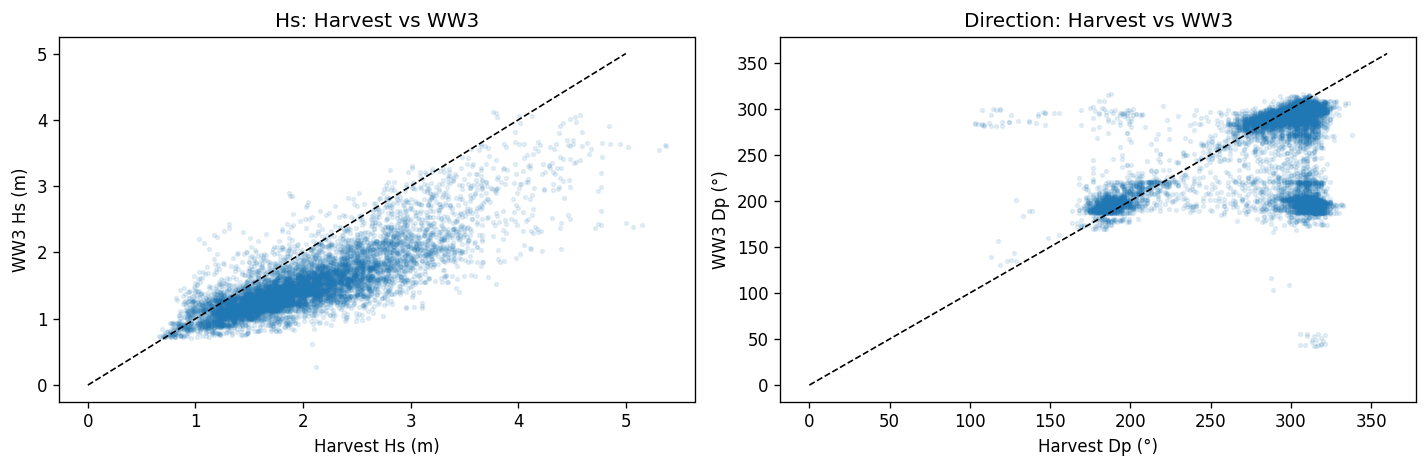

In [43]:
print('WW3 vs Harvest — how well do they agree offshore?')
skill_metrics(aligned_ww3['Hs_harvest'].values, aligned_ww3['Hs_ww3'].values,
              'WW3 vs Harvest Hs')

r, p = stats.pearsonr(aligned_ww3['Dp_harvest'], aligned_ww3['Dp_ww3'])
print(f'\nDirection correlation (Harvest vs WW3): r={r:.3f} (p={p:.2e})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(aligned_ww3['Hs_harvest'], aligned_ww3['Hs_ww3'], 
                alpha=0.1, s=5)
axes[0].plot([0, 5], [0, 5], 'k--', lw=1)
axes[0].set_xlabel('Harvest Hs (m)')
axes[0].set_ylabel('WW3 Hs (m)')
axes[0].set_title('Hs: Harvest vs WW3')

axes[1].scatter(aligned_ww3['Dp_harvest'], aligned_ww3['Dp_ww3'],
                alpha=0.1, s=5)
axes[1].plot([0, 360], [0, 360], 'k--', lw=1)
axes[1].set_xlabel('Harvest Dp (°)')
axes[1].set_ylabel('WW3 Dp (°)')
axes[1].set_title('Direction: Harvest vs WW3')

plt.tight_layout()
plt.show()